# 01. Análise Exploratória de Dados (EDA) - Clima RS

Este notebook faz a exploração inicial dos dados sintéticos gerados para simular a climatologia e hidrologia do Rio Grande do Sul.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Configurar estilo de gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carregando dados brutos do INMET e ANA

In [3]:
df_inmet = pd.read_csv('../data/raw/inmet.csv')
df_ana = pd.read_csv('../data/raw/ana.csv')

df_inmet['timestamp'] = pd.to_datetime(df_inmet['timestamp'])
df_ana['timestamp'] = pd.to_datetime(df_ana['timestamp'])

print("INMET shape:", df_inmet.shape)
print("ANA shape:", df_ana.shape)
print("Features INMET:", list(df_inmet.columns))
print("Features ANA:", list(df_ana.columns))

INMET shape: (56929, 6)
ANA shape: (56929, 3)
Features INMET: ['timestamp', 'precipitacao', 'velocidade_vento', 'temperatura', 'umidade', 'pressao']
Features ANA: ['timestamp', 'nivel_rio', 'vazao']


## 2. Mesclando as Bases

In [4]:
df = pd.merge(df_inmet, df_ana, on='timestamp', how='inner')
print("Merged shape:", df.shape)
df.head()

Merged shape: (56929, 8)


,timestamp,precipitacao,velocidade_vento,temperatura,umidade,pressao,nivel_rio,vazao
0,2018-01-01 00:00:00,0.0,5.08,20.4,85.7,1009.4,202.9,52.7
1,2018-01-01 01:00:00,0.0,5.66,19.8,78.3,1006.8,208.6,51.6
2,2018-01-01 02:00:00,0.0,3.89,16.9,87.4,1009.0,201.4,48.3
3,2018-01-01 03:00:00,0.0,10.48,17.8,75.1,1007.8,201.5,49.6
4,2018-01-01 04:00:00,0.0,3.80,21.0,78.8,1014.1,201.5,51.3


## 3. Estatísticas Descritivas

In [5]:
df.describe()

,timestamp,precipitacao,velocidade_vento,temperatura,umidade,pressao,nivel_rio,vazao
count,56929,56929.000000,56929.000000,56929.000000,56929.000000,56929.000000,56929.000000,56929.000000
mean,2021-04-01 00:00:00,0.435771,9.274471,18.119436,75.159873,1010.961434,348.251914,398.537262
min,2018-01-01 00:00:00,0.000000,3.000000,-1.900000,49.700000,971.300000,192.200000,46.700000
25%,2019-08-17 00:00:00,0.000000,4.740000,12.900000,70.400000,1009.000000,250.200000,110.400000
50%,2021-04-01 00:00:00,0.000000,7.200000,18.200000,75.100000,1011.100000,309.600000,211.100000
75%,2022-11-15 00:00:00,0.000000,11.460000,23.300000,79.700000,1013.200000,390.000000,388.400000
max,2024-06-30 00:00:00,82.640000,76.580000,38.400000,100.000000,1023.900000,2430.300000,15715.200000
std,NaN,2.361735,6.700612,6.952771,6.785185,3.848439,194.193637,1104.212521


## 4. Visualizando Padrões Sazonais e Diários

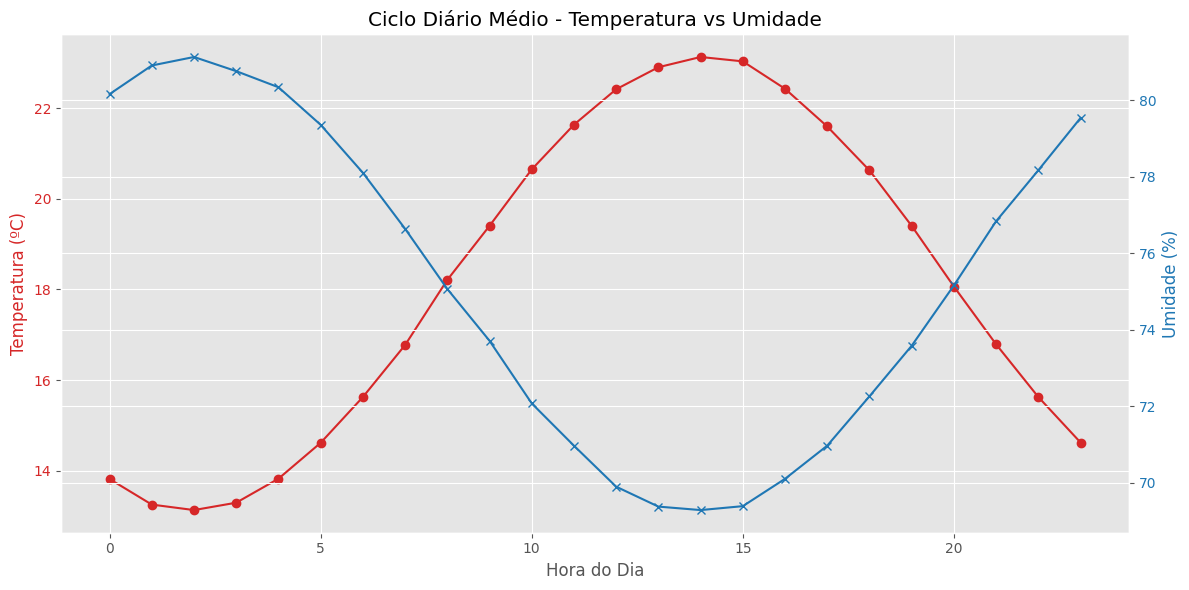

c:\Users\vinic\anaconda3\envs\watenv\python.exe


In [ ]:
# Ciclo de 24 horas - Temperatura vs Umidade
df['hour'] = df['timestamp'].dt.hour
hourly_stats = df.groupby('hour')[['temperatura', 'umidade']].mean()

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Hora do Dia')
ax1.set_ylabel('Temperatura (ºC)', color=color)
ax1.plot(hourly_stats.index, hourly_stats['temperatura'], color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Umidade (%)', color=color)
ax2.plot(hourly_stats.index, hourly_stats['umidade'], color=color, marker='x')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ciclo Diário Médio - Temperatura vs Umidade')
fig.tight_layout()
plt.show()



## 5. Matriz de Correlação das Variáveis

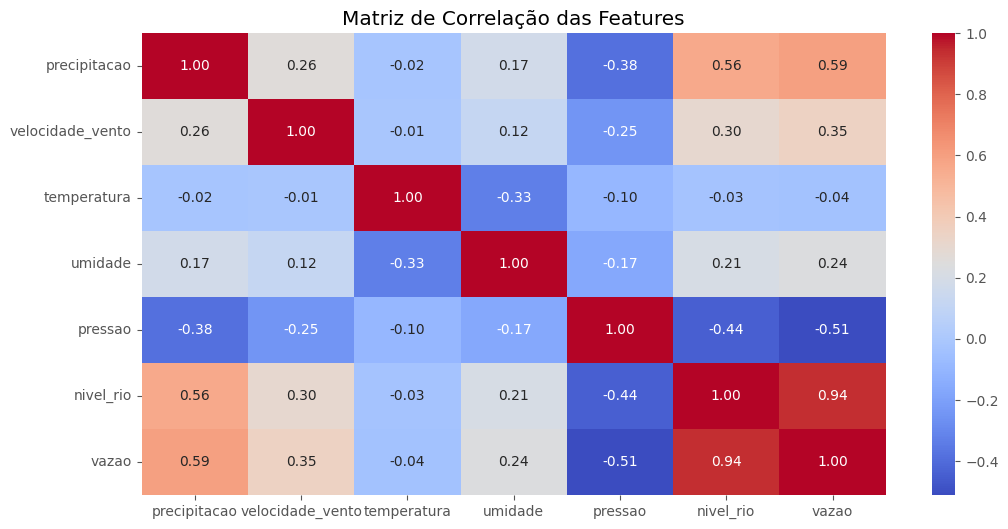

In [7]:
corr = df.drop(columns=['timestamp', 'hour']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Features')
plt.show()

## 6. Identificando Picos Históricos de Nível do Rio

In [8]:
top_levels = df.sort_values(by='nivel_rio', ascending=False).head(10)
print("Top 10 Maiores Níveis Registrados:")
print(top_levels[['timestamp', 'nivel_rio', 'precipitacao', 'vazao']])

Top 10 Maiores Níveis Registrados:
                timestamp  nivel_rio  precipitacao    vazao
55604 2024-05-05 20:00:00     2430.3         13.32  15622.1
55605 2024-05-05 21:00:00     2428.2         27.25  15715.2
55608 2024-05-06 00:00:00     2422.8         27.62  15620.8
55606 2024-05-05 22:00:00     2422.8         13.27  15642.8
55603 2024-05-05 19:00:00     2422.0         42.14  15699.7
55609 2024-05-06 01:00:00     2414.9         15.67  15571.9
55597 2024-05-05 13:00:00     2414.8         46.45  15549.3
55594 2024-05-05 10:00:00     2412.1         57.51  15483.2
55610 2024-05-06 02:00:00     2411.6         14.79  15520.9
55607 2024-05-05 23:00:00     2409.6          9.52  15518.5
